In [1]:
!pip install pyroomacoustics librosa soundfile pandas matplotlib

In [2]:
import os
import shutil
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import pyroomacoustics as pra

In [3]:
base_dir = "/Users/xuyixuan/Desktop/synthetic_brir_balanced_840"

candidate_audio_dir = os.path.join(base_dir, "candidate_audio")
candidate_feature_dir = os.path.join(base_dir, "candidate_features")

final_audio_dir = os.path.join(base_dir, "audio")
final_feature_dir = os.path.join(base_dir, "features")

for d in [candidate_audio_dir, candidate_feature_dir, final_audio_dir, final_feature_dir]:
    os.makedirs(d, exist_ok=True)

print("Dataset folder:", base_dir)

Dataset folder: /Users/xuyixuan/Desktop/synthetic_brir_balanced_840


In [4]:
sr = 16000
rir_length = 0.5
max_order = 10
ear_distance = 0.18

rooms = [
    [6.0, 4.0, 3.0],
    [8.0, 5.0, 3.0],
    [9.0, 6.0, 3.0],
    [10.0, 7.0, 3.0],
]

absorptions = [0.1, 0.2, 0.35, 0.5, 0.65, 0.8]

source_positions = [
    [1.0, 1.2, 1.5],
    [1.0, 2.0, 1.5],
    [1.0, 3.0, 1.5],
    [2.0, 1.5, 1.5],
    [2.0, 2.5, 1.5],
    [3.0, 2.0, 1.5],
]

listener_positions = [
    [1.5, 1.3, 1.5],
    [2.0, 1.3, 1.5],
    [2.5, 1.3, 1.5],
    [3.0, 1.3, 1.5],
    [3.5, 1.3, 1.5],
    [4.0, 1.3, 1.5],
    [4.5, 1.3, 1.5],

    [1.5, 2.5, 1.5],
    [2.0, 2.5, 1.5],
    [2.5, 2.5, 1.5],
    [3.0, 2.5, 1.5],
    [3.5, 2.5, 1.5],
    [4.0, 2.5, 1.5],
    [4.5, 2.5, 1.5],

    [1.5, 3.2, 1.5],
    [2.0, 3.2, 1.5],
    [2.5, 3.2, 1.5],
    [3.0, 3.2, 1.5],
    [3.5, 3.2, 1.5],
    [4.0, 3.2, 1.5],
]

expected_candidates = len(rooms) * len(absorptions) * len(source_positions) * len(listener_positions)
print("Expected candidate samples:", expected_candidates)

Expected candidate samples: 2880


In [7]:
def is_position_inside_room(pos, room_dim, margin=0.2):
    x, y, z = pos
    return (
        margin <= x <= room_dim[0] - margin and
        margin <= y <= room_dim[1] - margin and
        margin <= z <= room_dim[2] - margin
    )


def brir_to_logmel(brir, sr=16000, n_mels=64, n_fft=512, hop_length=256):
    features = []

    for ch in range(2):
        mel = librosa.feature.melspectrogram(
            y=brir[ch],
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )
        logmel = librosa.power_to_db(mel + 1e-12)
        features.append(logmel)

    return np.stack(features, axis=0).transpose(0, 2, 1).astype(np.float32)


def compute_c80(ir, sr):
    energy = ir ** 2
    split = int(0.08 * sr)

    early = np.sum(energy[:split])
    late = np.sum(energy[split:])

    if late <= 1e-12:
        return np.nan

    return 10 * np.log10((early + 1e-12) / (late + 1e-12))


def compute_drr_peak(ir, sr, direct_ms=2.5):
    energy = ir ** 2
    peak_idx = np.argmax(np.abs(ir))

    half_win = int((direct_ms / 1000.0) * sr / 2)
    start = max(0, peak_idx - half_win)
    end = min(len(ir), peak_idx + half_win)

    direct = np.sum(energy[start:end])
    reverb = np.sum(energy) - direct

    if reverb <= 1e-12:
        return np.nan

    return 10 * np.log10((direct + 1e-12) / (reverb + 1e-12))


def compute_ild(brir):
    left = brir[0]
    right = brir[1]

    left_rms = np.sqrt(np.mean(left ** 2))
    right_rms = np.sqrt(np.mean(right ** 2))

    return 20 * np.log10((left_rms + 1e-12) / (right_rms + 1e-12))


def compute_itd_peak(brir, sr):
    left = brir[0]
    right = brir[1]

    left_peak = np.argmax(np.abs(left))
    right_peak = np.argmax(np.abs(right))

    return (left_peak - right_peak) / sr * 1000

In [12]:
rows = []
idx = 0
target_len = int(rir_length * sr)

for room_id, room_dim in enumerate(rooms):
    for absorption in absorptions:
        V = room_dim[0] * room_dim[1] * room_dim[2]
        S = 2 * (room_dim[0]*room_dim[1] + room_dim[0]*room_dim[2] + room_dim[1]*room_dim[2])
        rt60 = 0.161 * V / (absorption * S)

        for source_id, source_pos in enumerate(source_positions):
            if not is_position_inside_room(source_pos, room_dim):
                continue

            for listener_id, listener_center in enumerate(listener_positions):
                if not is_position_inside_room(listener_center, room_dim):
                    continue

                listener_center = np.array(listener_center)

                left_ear = listener_center + np.array([0, -ear_distance / 2, 0])
                right_ear = listener_center + np.array([0, ear_distance / 2, 0])

                if not is_position_inside_room(left_ear, room_dim):
                    continue
                if not is_position_inside_room(right_ear, room_dim):
                    continue

                mic_positions = np.c_[left_ear, right_ear]

                room = pra.ShoeBox(
                    room_dim,
                    fs=sr,
                    materials=pra.Material(absorption),
                    max_order=max_order
                )

                room.add_source(source_pos)
                room.add_microphone_array(pra.MicrophoneArray(mic_positions, room.fs))
                room.compute_rir()

                left_rir = room.rir[0][0]
                right_rir = room.rir[1][0]

                left_rir = librosa.util.fix_length(left_rir, size=target_len)
                right_rir = librosa.util.fix_length(right_rir, size=target_len)

                brir = np.stack([left_rir, right_rir], axis=0)
                mono_ir = (brir[0] + brir[1]) / 2.0

                drr = compute_drr_peak(mono_ir, sr)
                c80 = compute_c80(mono_ir, sr)
                ild = compute_ild(brir)
                itd = compute_itd_peak(brir, sr)

                if np.isnan(drr):
                    drr = 0.0
                if np.isnan(c80):
                    c80 = 0.0
                if np.isnan(ild):
                    ild = 0.0
                if np.isnan(itd):
                    itd = 0.0

                wav_name = f"candidate_{idx:05d}.wav"
                npy_name = f"candidate_{idx:05d}.npy"

                wav_path = os.path.join(candidate_audio_dir, wav_name)
                npy_path = os.path.join(candidate_feature_dir, npy_name)

                sf.write(wav_path, brir.T, sr)

                feature = brir_to_logmel(brir, sr=sr)
                np.save(npy_path, feature)

                rows.append({
                    "candidate_id": idx,
                    "filename": wav_name,
                    "feature_file": npy_name,

                    "room_id": room_id,
                    "room_x": room_dim[0],
                    "room_y": room_dim[1],
                    "room_z": room_dim[2],

                    "absorption": absorption,
                    "RT60": rt60,

                    "source_id": source_id,
                    "source_x": source_pos[0],
                    "source_y": source_pos[1],
                    "source_z": source_pos[2],

                    "listener_id": listener_id,
                    "listener_x": listener_center[0],
                    "listener_y": listener_center[1],
                    "listener_z": listener_center[2],

                    "DRR": drr,
                    "C80": c80,
                    "ILD": ild,
                    "ITD_ms": itd,
                })

                idx += 1

df = pd.DataFrame(rows)

print("Candidate samples:", len(df))
print(df.head())

Candidate samples: 2880
   candidate_id             filename         feature_file  room_id  room_x  \
0             0  candidate_00000.wav  candidate_00000.npy        0     6.0   
1             1  candidate_00001.wav  candidate_00001.npy        0     6.0   
2             2  candidate_00002.wav  candidate_00002.npy        0     6.0   
3             3  candidate_00003.wav  candidate_00003.npy        0     6.0   
4             4  candidate_00004.wav  candidate_00004.npy        0     6.0   

   room_y  room_z  absorption      RT60  source_id  ...  source_y  source_z  \
0     4.0     3.0         0.1  1.073333          0  ...       1.2       1.5   
1     4.0     3.0         0.1  1.073333          0  ...       1.2       1.5   
2     4.0     3.0         0.1  1.073333          0  ...       1.2       1.5   
3     4.0     3.0         0.1  1.073333          0  ...       1.2       1.5   
4     4.0     3.0         0.1  1.073333          0  ...       1.2       1.5   

   listener_id  listener_x  list

In [13]:
q1 = df["DRR"].quantile(1/3)
q2 = df["DRR"].quantile(2/3)

def drr_to_class(x):
    if x < q1:
        return 0
    elif x < q2:
        return 1
    else:
        return 2

df["DRR_class"] = df["DRR"].apply(drr_to_class)

print("DRR thresholds:")
print("Class 0: DRR <", q1)
print("Class 1:", q1, "<= DRR <", q2)
print("Class 2: DRR >=", q2)

print("\nCandidate class counts:")
print(df["DRR_class"].value_counts().sort_index())

DRR thresholds:
Class 0: DRR < -5.9014927095826435
Class 1: -5.9014927095826435 <= DRR < 0.17821109095202917
Class 2: DRR >= 0.17821109095202917

Candidate class counts:
DRR_class
0    960
1    960
2    960
Name: count, dtype: int64


In [14]:
balanced_df = (
    df.groupby("DRR_class", group_keys=False)
      .apply(lambda x: x.sample(n=280, random_state=42))
      .reset_index(drop=True)
)

print("Balanced class counts:")
print(balanced_df["DRR_class"].value_counts().sort_index())
print("Total balanced samples:", len(balanced_df))

Balanced class counts:
DRR_class
0    280
1    280
2    280
Name: count, dtype: int64
Total balanced samples: 840


/var/folders/54/ct0frh755j3ftw0stm_sbwh80000gn/T/ipykernel_79123/3788050396.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=280, random_state=42))


In [15]:
final_rows = []

for new_idx, row in balanced_df.iterrows():
    new_wav_name = f"{new_idx:04d}.wav"
    new_npy_name = f"{new_idx:04d}.npy"

    old_wav_path = os.path.join(candidate_audio_dir, row["filename"])
    old_npy_path = os.path.join(candidate_feature_dir, row["feature_file"])

    new_wav_path = os.path.join(final_audio_dir, new_wav_name)
    new_npy_path = os.path.join(final_feature_dir, new_npy_name)

    shutil.copy(old_wav_path, new_wav_path)
    shutil.copy(old_npy_path, new_npy_path)

    new_row = row.copy()
    new_row["filename"] = new_wav_name
    new_row["feature_file"] = new_npy_name
    final_rows.append(new_row)

final_df = pd.DataFrame(final_rows)

labels_path = os.path.join(base_dir, "labels.csv")
final_df.to_csv(labels_path, index=False)

print("Final labels saved:", labels_path)
print("Final total:", len(final_df))
print(final_df.head())

Final labels saved: /Users/xuyixuan/Desktop/synthetic_brir_balanced_840/labels.csv
Final total: 840
   candidate_id  filename feature_file  room_id  room_x  room_y  room_z  \
0          2246  0000.wav     0000.npy        3    10.0     7.0     3.0   
1           971  0001.wav     0001.npy        1     8.0     5.0     3.0   
2           786  0002.wav     0002.npy        1     8.0     5.0     3.0   
3          2326  0003.wav     0003.npy        3    10.0     7.0     3.0   
4          2380  0004.wav     0004.npy        3    10.0     7.0     3.0   

   absorption      RT60  source_id  ...  source_z  listener_id  listener_x  \
0        0.10  1.397107          4  ...       1.5            6         4.5   
1        0.35  0.349367          0  ...       1.5           11         3.5   
2        0.10  1.222785          3  ...       1.5            6         4.5   
3        0.20  0.698554          2  ...       1.5            6         4.5   
4        0.20  0.698554          5  ...       1.5          

In [16]:
audio_files = [f for f in os.listdir(final_audio_dir) if f.endswith(".wav")]
feature_files = [f for f in os.listdir(final_feature_dir) if f.endswith(".npy")]

print("Final audio files:", len(audio_files))
print("Final feature files:", len(feature_files))
print("Final CSV rows:", len(final_df))

print("\nFinal DRR class counts:")
print(final_df["DRR_class"].value_counts().sort_index())

print("\nLabel statistics:")
print(final_df[["DRR", "C80", "RT60", "ILD", "ITD_ms"]].describe())

Final audio files: 840
Final feature files: 840
Final CSV rows: 840

Final DRR class counts:
DRR_class
0    280
1    280
2    280
Name: count, dtype: int64

Label statistics:
              DRR         C80        RT60         ILD      ITD_ms
count  840.000000  840.000000  840.000000  840.000000  840.000000
mean    -2.300115   21.130311    0.483088    0.063542   -0.112054
std      6.523947   12.019746    0.392502    0.950978    2.409928
min    -14.109152    4.112832    0.134167   -8.381823  -20.812500
25%     -7.336343   10.479081    0.202657   -0.095152   -0.375000
50%     -3.135158   18.463307    0.279421    0.108081   -0.125000
75%      1.816711   29.934709    0.658636    0.379137    0.187500
max     27.630178   60.935548    1.397107    3.135673   18.500000


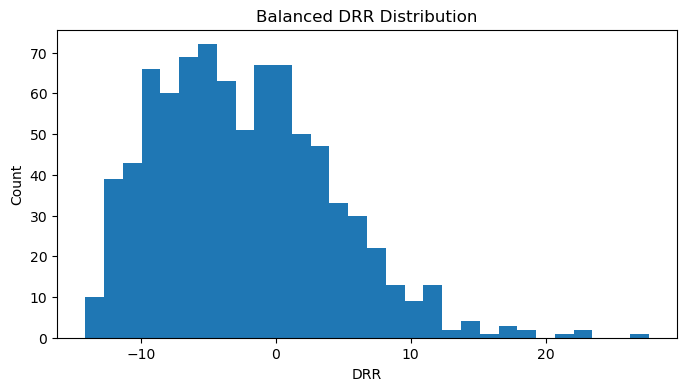

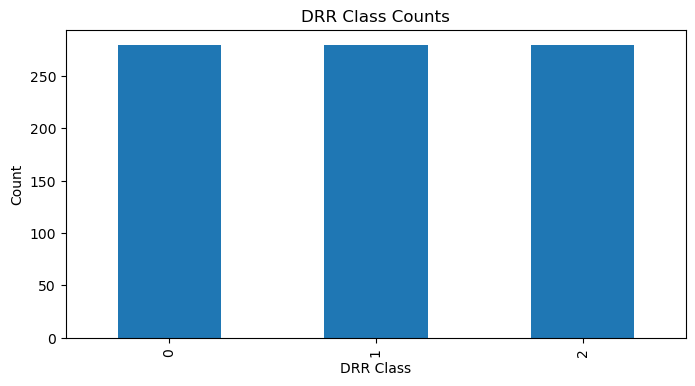

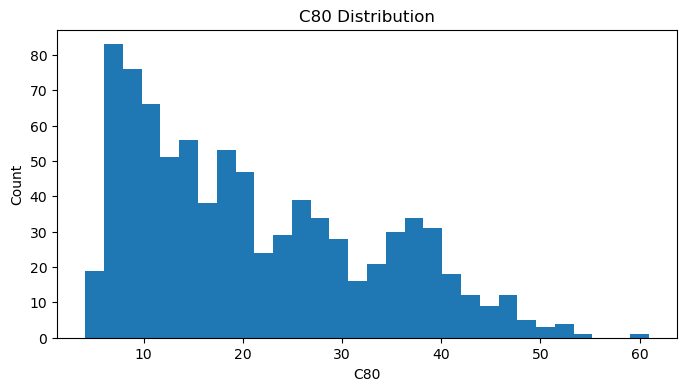

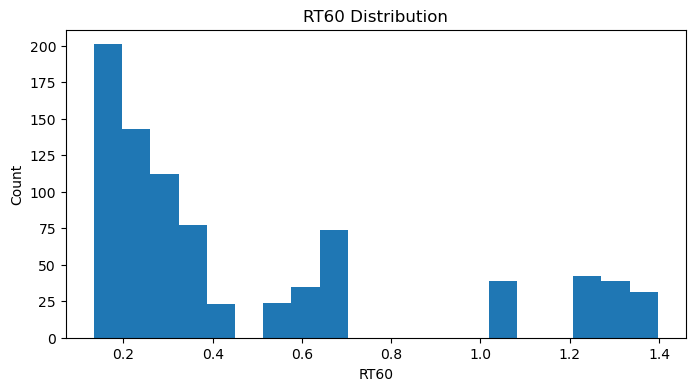

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(final_df["DRR"], bins=30)
plt.title("Balanced DRR Distribution")
plt.xlabel("DRR")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
final_df["DRR_class"].value_counts().sort_index().plot(kind="bar")
plt.title("DRR Class Counts")
plt.xlabel("DRR Class")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(final_df["C80"], bins=30)
plt.title("C80 Distribution")
plt.xlabel("C80")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(final_df["RT60"], bins=20)
plt.title("RT60 Distribution")
plt.xlabel("RT60")
plt.ylabel("Count")
plt.show()

WAV shape: (8000, 2)
Sample rate: 16000
Feature shape: (2, 32, 64)


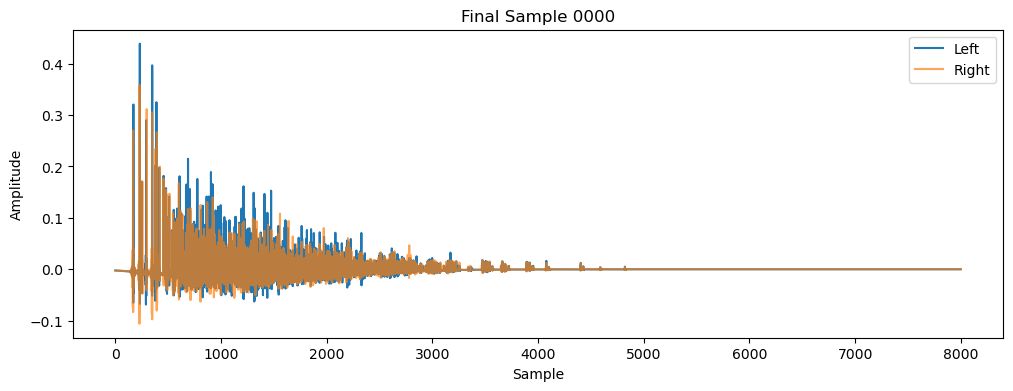

In [18]:
test_wav_path = os.path.join(final_audio_dir, "0000.wav")
test_npy_path = os.path.join(final_feature_dir, "0000.npy")

audio, fs = sf.read(test_wav_path)
feature = np.load(test_npy_path)

print("WAV shape:", audio.shape)
print("Sample rate:", fs)
print("Feature shape:", feature.shape)

plt.figure(figsize=(12, 4))
plt.plot(audio[:, 0], label="Left")
plt.plot(audio[:, 1], label="Right", alpha=0.7)
plt.title("Final Sample 0000")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()